# 1. Twitch API

In [11]:
from dotenv import load_dotenv
import os
import requests
import pandas as pd

load_dotenv()

True

In [12]:
CLIENT_ID = os.getenv("TWITCH_CLIENT_ID")
CLIENT_SECRET = os.getenv("TWITCH_CLIENT_SECRET")

print("CLIENT_ID found:", CLIENT_ID is not None)
print("CLIENT_SECRET found:", CLIENT_SECRET is not None)

CLIENT_ID found: True
CLIENT_SECRET found: True


In [13]:
auth_url = "https://id.twitch.tv/oauth2/token"

params = {
    "client_id": CLIENT_ID,
    "client_secret": CLIENT_SECRET,
    "grant_type": "client_credentials",
}

response = requests.post(auth_url, params=params)
print("Status code:", response.status_code)
print(response.json())

Status code: 200
{'access_token': 'h8e7k42x8tuv31l09x3196svvm1ijs', 'expires_in': 5635394, 'token_type': 'bearer'}


In [14]:
token_data = response.json()
ACCESS_TOKEN = token_data["access_token"]

headers = {"Client-ID": CLIENT_ID, "Authorization": f"Bearer {ACCESS_TOKEN}"}

streams_url = "https://api.twitch.tv/helix/streams"
streams_response = requests.get(streams_url, headers=headers, params={"first": 5})

print("Streams status:", streams_response.status_code)
streams_data = streams_response.json()
streams_data

Streams status: 200


{'data': [{'id': '316376739682',
   'user_id': '558530984',
   'user_login': 'echo_esports',
   'user_name': 'Echo_Esports',
   'game_id': '18122',
   'game_name': 'World of Warcraft',
   'type': 'live',
   'title': 'Echo Race to World First Advanced by AMD : Midnight Season 1 | Day 20 | !amd',
   'viewer_count': 88404,
   'started_at': '2026-04-05T03:01:16Z',
   'language': 'en',
   'thumbnail_url': 'https://static-cdn.jtvnw.net/previews-ttv/live_user_echo_esports-{width}x{height}.jpg',
   'tag_ids': [],
   'tags': ['English', 'DropsEnabled'],
   'is_mature': False},
  {'id': '315757706709',
   'user_id': '922408450',
   'user_login': 'anarabdullaev',
   'user_name': 'anarabdullaev',
   'game_id': '509672',
   'game_name': 'IRL',
   'type': 'live',
   'title': 'Стая у деда в Варениковке, бабулю с прошедшим поздравляем и проводы Давидика ЛЕРЫ НЕ БУДЕТ!',
   'viewer_count': 55141,
   'started_at': '2026-04-06T14:37:58Z',
   'language': 'ru',
   'thumbnail_url': 'https://static-cdn.jtvnw

In [15]:
df = pd.DataFrame(streams_data["data"])
df[
    [
        "user_id",
        "user_name",
        "game_id",
        "game_name",
        "type",
        "viewer_count",
        "title",
        "started_at",
        "language",
        "is_mature",
        "tags",
    ]
].head()

,user_id,user_name,game_id,game_name,type,viewer_count,title,started_at,language,is_mature,tags
0,558530984,Echo_Esports,18122,World of Warcraft,live,88404,Echo Race to World First Advanced by AMD : Mid...,2026-04-05T03:01:16Z,en,False,"[English, DropsEnabled]"
1,922408450,anarabdullaev,509672,IRL,live,55141,"Стая у деда в Варениковке, бабулю с прошедшим ...",2026-04-06T14:37:58Z,ru,False,[Русский]
2,77827128,Tumblurr,1863222988,Kings League,live,37958,🏆⚽KINGS LEAGUE SETTIMA GIORNATA | 🐎STALLIONS v...,2026-04-06T14:39:17Z,it,False,[Italiano]
3,233741947,StRoGo,32399,Counter-Strike,live,31553,🔴 s1mple 0:1 Voca | PGL Bucharest 2026,2026-04-06T12:37:39Z,ru,False,"[Русский, English]"
4,238813810,eliasn97,509663,Special Events,live,30956,The Icon League Season Four MD-05 Live aus Ber...,2026-04-06T15:19:52Z,de,False,"[Deutsch, GOTY]"


# 2. EDA

In [16]:
from dotenv import load_dotenv
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

load_dotenv()

sns.set_theme(style="whitegrid", context="notebook")

CLIENT_ID = os.getenv("TWITCH_CLIENT_ID")
CLIENT_SECRET = os.getenv("TWITCH_CLIENT_SECRET")

if not CLIENT_ID or not CLIENT_SECRET:
    raise ValueError("TWITCH_CLIENT_ID / TWITCH_CLIENT_SECRET not found in .env")


def get_app_token(client_id: str, client_secret: str) -> str:
    url = "https://id.twitch.tv/oauth2/token"
    params = {
        "client_id": client_id,
        "client_secret": client_secret,
        "grant_type": "client_credentials",
    }
    response = requests.post(url, params=params, timeout=30)
    response.raise_for_status()
    return response.json()["access_token"]


def get_headers(client_id: str, token: str) -> dict:
    return {
        "Client-ID": client_id,
        "Authorization": f"Bearer {token}",
    }


def collect_streams_snapshot(
    client_id: str,
    client_secret: str,
    max_pages: int = 5,
    page_size: int = 100,
    sleep_sec: float = 0.4,
) -> pd.DataFrame:
    token = get_app_token(client_id, client_secret)
    headers = get_headers(client_id, token)
    url = "https://api.twitch.tv/helix/streams"

    all_rows = []
    cursor = None
    collected_at = pd.Timestamp.utcnow()

    for page_num in range(1, max_pages + 1):
        params = {"first": page_size}
        if cursor:
            params["after"] = cursor

        response = requests.get(url, headers=headers, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()

        rows = payload.get("data", [])
        if not rows:
            print(f"Page {page_num}: no more data available")
            break

        print(f"Page {page_num}: fetched {len(rows)} rows")
        all_rows.extend(rows)

        cursor = payload.get("pagination", {}).get("cursor")
        if not cursor:
            print("No next page available")
            break

        time.sleep(sleep_sec)

    df = pd.DataFrame(all_rows)

    if df.empty:
        return df

    df["collected_at"] = collected_at

    df["started_at"] = pd.to_datetime(df["started_at"], utc=True)
    df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)

    df["stream_duration_hours"] = (
        df["collected_at"] - df["started_at"]
    ).dt.total_seconds() / 3600

    if "tags" in df.columns:
        df["tags"] = df["tags"].apply(
            lambda x: ", ".join(x) if isinstance(x, list) else x
        )

    desired_cols = [
        "id",
        "user_id",
        "user_login",
        "user_name",
        "game_id",
        "game_name",
        "type",
        "title",
        "viewer_count",
        "started_at",
        "collected_at",
        "stream_duration_hours",
        "language",
        "tags",
        "is_mature",
        "thumbnail_url",
    ]
    existing_cols = [c for c in desired_cols if c in df.columns]
    other_cols = [c for c in df.columns if c not in existing_cols]
    df = df[existing_cols + other_cols]

    return df


def append_snapshot_to_csv(
    df: pd.DataFrame,
    csv_path: str = "data/raw/twitch_streams_snapshots.csv",
) -> None:
    if df.empty:
        print("DataFrame is empty, nothing to save")
        return

    path = Path(csv_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    file_exists = path.exists()
    df.to_csv(path, mode="a", header=not file_exists, index=False)
    print(f"Saved {len(df)} rows to {path}")


# === run ===
df_snapshot = collect_streams_snapshot(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    max_pages=5,  # 5 pages * 100 items per page = 500 streams max
    page_size=100,
    sleep_sec=0.5,
)

print(df_snapshot.shape)
display(df_snapshot.head())

append_snapshot_to_csv(df_snapshot)

/var/folders/sr/p3kpr51n4hs1q5w3zd7p_j0c0000gn/T/ipykernel_74358/2341422948.py:54: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  collected_at = pd.Timestamp.utcnow()


Page 1: fetched 100 rows
Page 2: fetched 100 rows
Page 3: fetched 100 rows
Page 4: fetched 100 rows
Page 5: fetched 100 rows
(500, 17)


,id,user_id,user_login,user_name,game_id,game_name,type,title,viewer_count,started_at,collected_at,stream_duration_hours,language,tags,is_mature,thumbnail_url,tag_ids
0,316376739682,558530984,echo_esports,Echo_Esports,18122,World of Warcraft,live,Echo Race to World First Advanced by AMD : Mid...,88404,2026-04-05 03:01:16+00:00,2026-04-06 15:52:01.143869+00:00,36.845873,en,"English, DropsEnabled",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
1,315757706709,922408450,anarabdullaev,anarabdullaev,509672,IRL,live,"Стая у деда в Варениковке, бабулю с прошедшим ...",55141,2026-04-06 14:37:58+00:00,2026-04-06 15:52:01.143869+00:00,1.234207,ru,Русский,False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
2,316719249895,77827128,tumblurr,Tumblurr,1863222988,Kings League,live,🏆⚽KINGS LEAGUE SETTIMA GIORNATA | 🐎STALLIONS v...,37958,2026-04-06 14:39:17+00:00,2026-04-06 15:52:01.143869+00:00,1.212262,it,Italiano,False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
3,315815733972,233741947,strogo,StRoGo,32399,Counter-Strike,live,🔴 s1mple 0:1 Voca | PGL Bucharest 2026,31553,2026-04-06 12:37:39+00:00,2026-04-06 15:52:01.143869+00:00,3.239484,ru,"Русский, English",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
4,316719688423,238813810,eliasn97,eliasn97,509663,Special Events,live,The Icon League Season Four MD-05 Live aus Ber...,30956,2026-04-06 15:19:52+00:00,2026-04-06 15:52:01.143869+00:00,0.535873,de,"Deutsch, GOTY",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]


Saved 500 rows to data/raw/twitch_streams_snapshots.csv


In [17]:
df_all = pd.read_csv("data/raw/twitch_streams_snapshots.csv")
print(df_all.shape)
df_all.head()

(1000, 17)


,id,user_id,user_login,user_name,game_id,game_name,type,title,viewer_count,started_at,collected_at,stream_duration_hours,language,tags,is_mature,thumbnail_url,tag_ids
0,316376739682,558530984,echo_esports,Echo_Esports,18122.0,World of Warcraft,live,Echo Race to World First Advanced by AMD : Mid...,80966,2026-04-05 03:01:16+00:00,2026-04-06 14:41:51.346066+00:00,35.676485,en,"English, DropsEnabled",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
1,316935593062,21681549,pgl,PGL,32399.0,Counter-Strike,live,[A] Astralis vs. The MongolZ - PGL Bucharest 2...,28248,2026-04-06 06:48:02+00:00,2026-04-06 14:41:51.346066+00:00,7.897041,en,"Esports, English",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
2,315815733972,233741947,strogo,StRoGo,32399.0,Counter-Strike,live,🔴 s1mple 0:0 Voca | PGL Bucharest 2026,25660,2026-04-06 12:37:39+00:00,2026-04-06 14:41:51.346066+00:00,2.070096,ru,"Русский, English",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
3,315771240819,49207184,fps_shaka,fps_shaka,55453844.0,Street Fighter 6,live,APEXやるぞー,21361,2026-04-06 07:40:18+00:00,2026-04-06 14:41:51.346066+00:00,7.025929,ja,日本語,False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]
4,316870780261,38759871,bysl4m,bySL4M,32399.0,Counter-Strike,live,[RU] Astralis [1:0] The MongolZ | BO3 | PGL Bu...,15325,2026-04-06 06:33:04+00:00,2026-04-06 14:41:51.346066+00:00,8.146485,ru,"Русский, SL4M, PGLBucharest2026",False,https://static-cdn.jtvnw.net/previews-ttv/live...,[]


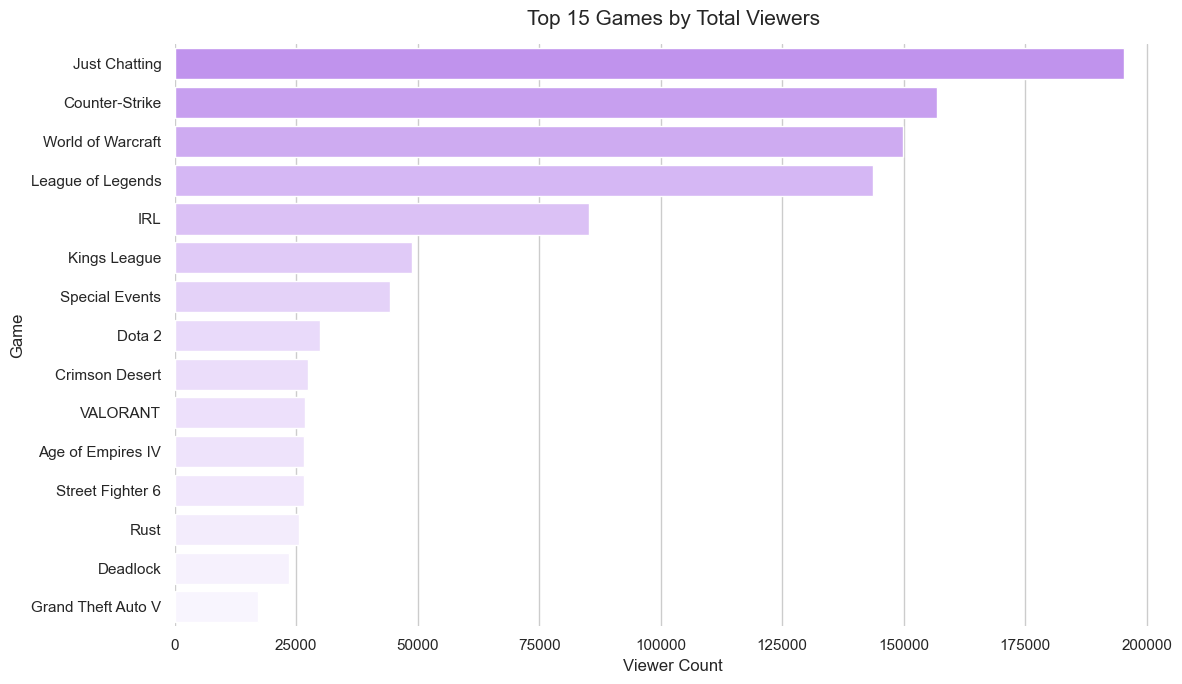

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

top_games = (
    df_snapshot.groupby("game_name", as_index=False)["viewer_count"]
    .sum()
    .sort_values("viewer_count", ascending=False)
    .head(15)
)

plot_data = top_games.sort_values("viewer_count", ascending=False)
lilac_palette = sns.blend_palette(
    ["#c084fc", "#d8b4fe", "#e9d5ff", "#efe1ff", "#f8f4ff"],
    n_colors=len(plot_data),
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_data,
    x="viewer_count",
    y="game_name",
    hue="game_name",
    palette=lilac_palette,
    legend=False,
)

ax.set_title("Top 15 Games by Total Viewers", fontsize=15, pad=14)
ax.set_xlabel("Viewer Count")
ax.set_ylabel("Game")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

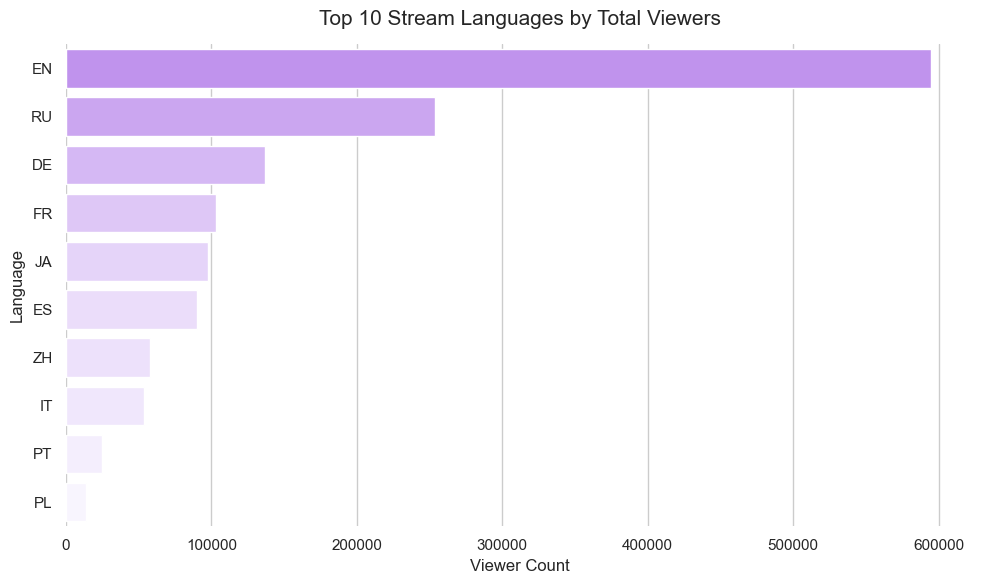

,language,viewer_count
5,EN,594563
17,RU,253911
3,DE,137048
8,FR,103206
10,JA,97866
6,ES,90198
21,ZH,58085
9,IT,53385
15,PT,25053
14,PL,14069


In [19]:
language_viewers = (
    df_snapshot.assign(
        language=df_snapshot["language"]
        .fillna("unknown")
        .replace("", "unknown")
        .str.upper()
    )
    .groupby("language", as_index=False)["viewer_count"]
    .sum()
    .sort_values("viewer_count", ascending=False)
    .head(10)
)

soft_lilac_palette = sns.blend_palette(
    ["#c084fc", "#d8b4fe", "#e9d5ff", "#efe1ff", "#f8f4ff"],
    n_colors=len(language_viewers),
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=language_viewers,
    x="viewer_count",
    y="language",
    hue="language",
    palette=soft_lilac_palette,
    legend=False,
)

ax.set_title("Top 10 Stream Languages by Total Viewers", fontsize=15, pad=14)
ax.set_xlabel("Viewer Count")
ax.set_ylabel("Language")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

language_viewers

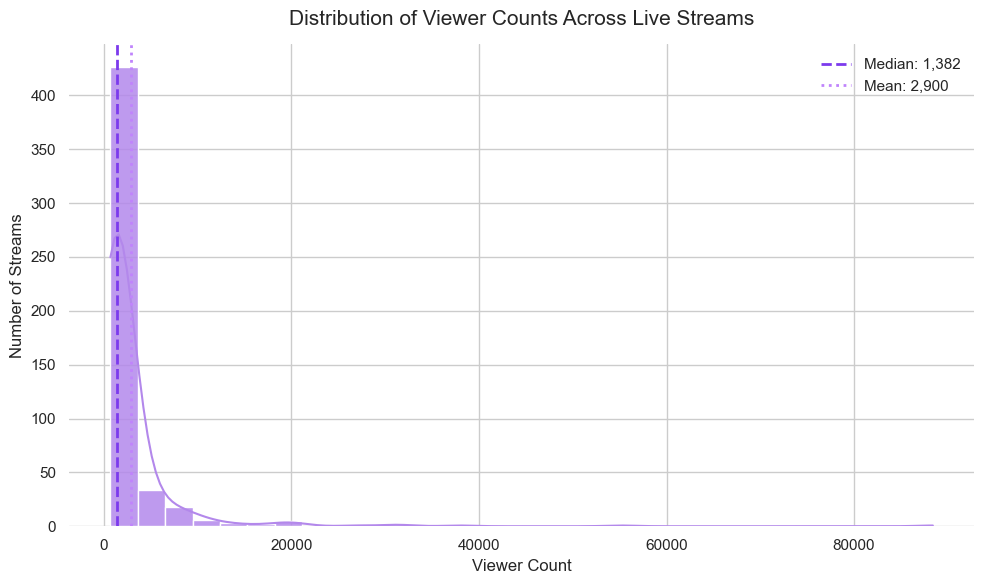

count      500.000000
mean      2900.332000
std       5959.635257
min        688.000000
25%        961.500000
50%       1382.500000
75%       2472.000000
max      88404.000000
Name: viewer_count, dtype: float64

In [20]:
viewer_dist = df_snapshot["viewer_count"].dropna()
median_viewers = viewer_dist.median()
mean_viewers = viewer_dist.mean()

plt.figure(figsize=(10, 6))
ax = sns.histplot(
    viewer_dist,
    bins=30,
    kde=True,
    color="#b388eb",
    edgecolor="white",
    alpha=0.85,
)

ax.axvline(
    median_viewers,
    color="#7c3aed",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_viewers:,.0f}",
)
ax.axvline(
    mean_viewers,
    color="#c084fc",
    linestyle=":",
    linewidth=2,
    label=f"Mean: {mean_viewers:,.0f}",
)

ax.set_title("Distribution of Viewer Counts Across Live Streams", fontsize=15, pad=14)
ax.set_xlabel("Viewer Count")
ax.set_ylabel("Number of Streams")
ax.legend(frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

viewer_dist.describe()

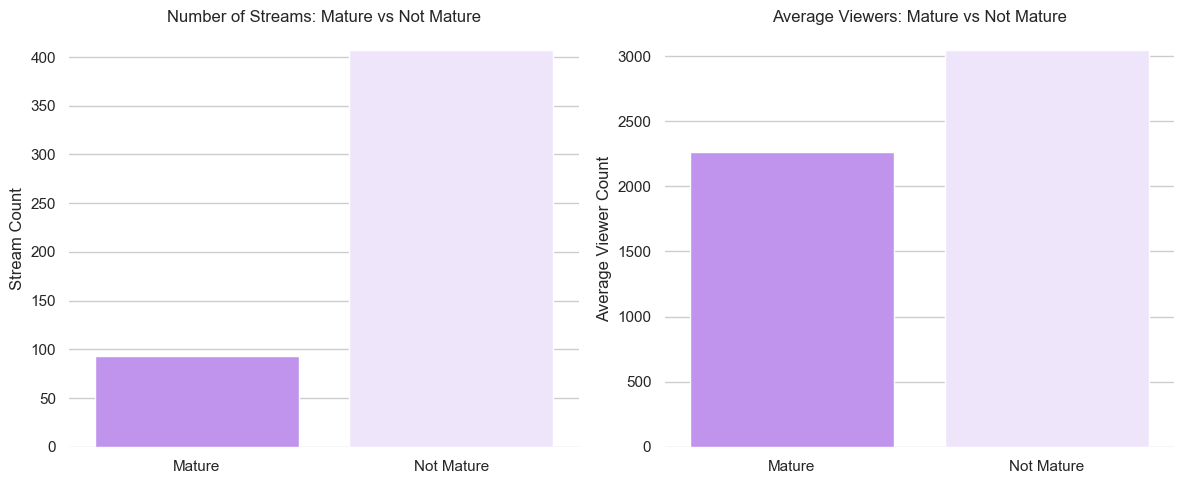

,mature_label,total_viewers,avg_viewers,stream_count
0,Mature,210816,2266.838710,93
1,Not Mature,1239350,3045.085995,407


In [21]:
mature_summary = (
    df_snapshot.assign(
        mature_label=df_snapshot["is_mature"].map({True: "Mature", False: "Not Mature"})
    )
    .groupby("mature_label", as_index=False)
    .agg(
        total_viewers=("viewer_count", "sum"),
        avg_viewers=("viewer_count", "mean"),
        stream_count=("viewer_count", "size"),
    )
)

mature_palette = ["#c084fc", "#efe1ff"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=mature_summary,
    x="mature_label",
    y="stream_count",
    hue="mature_label",
    palette=mature_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Number of Streams: Mature vs Not Mature")
axes[0].set_xlabel("")
axes[0].set_ylabel("Stream Count")

sns.barplot(
    data=mature_summary,
    x="mature_label",
    y="avg_viewers",
    hue="mature_label",
    palette=mature_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Average Viewers: Mature vs Not Mature")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average Viewer Count")

for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

mature_summary